## This notebook make a plot showing SCF. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import nuttall
from matplotlib.colors import LogNorm
import pkfuncs as pfunc
import scipy
from scipy.signal import windows
import plot_scripts as plts
import os
plt.style.use("mplstyle")

/var/folders/1v/cbxr_1rs0yb7884f6y71fxyw0000gn/T/ipykernel_12693/3727307318.py:181: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


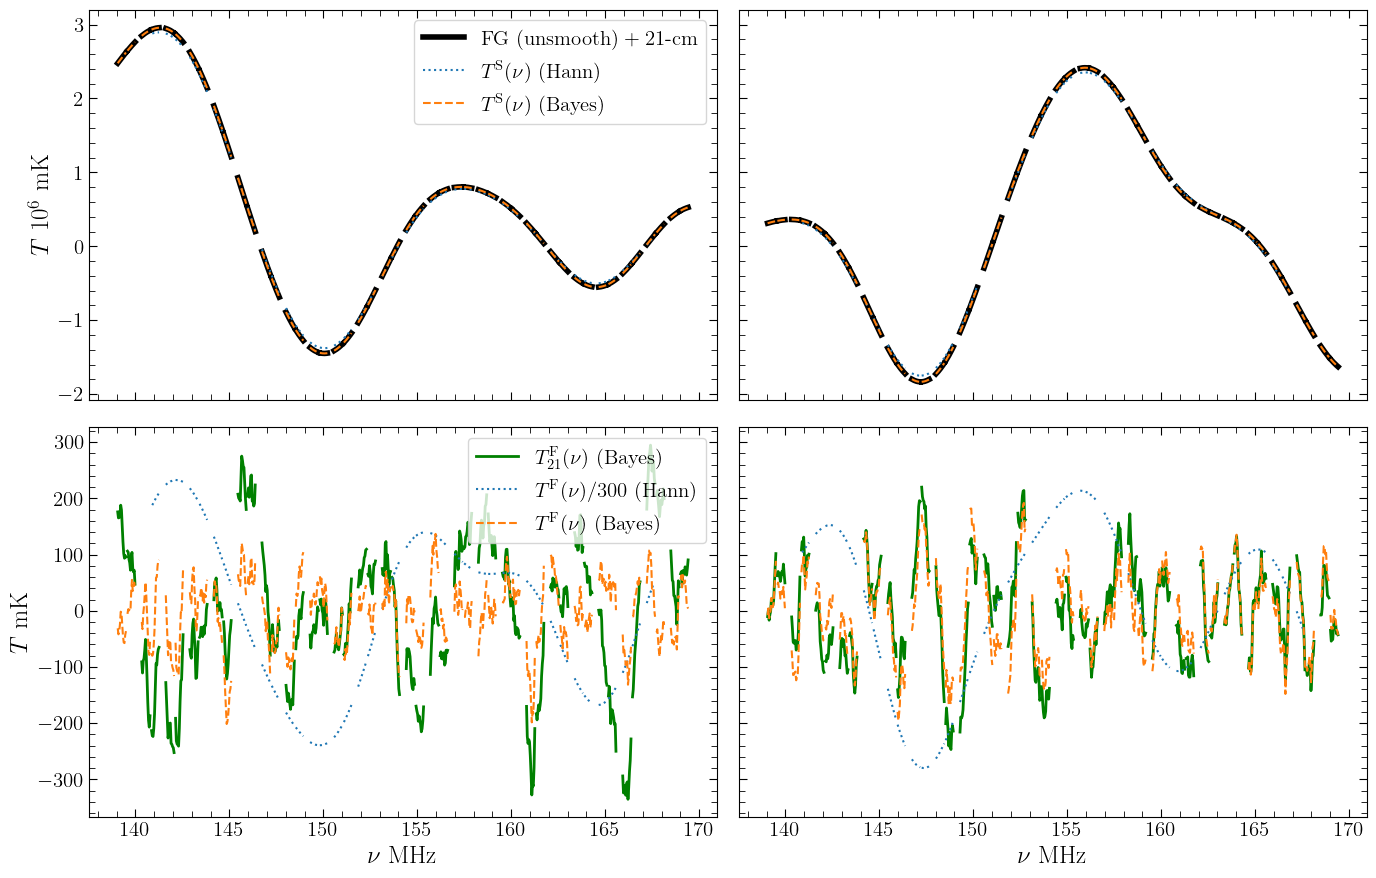

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# --- Input Model Parameters ---
n = 2.0
N = 768
dnuc = 40e-3             # MHz
r = 9209.714526830916    # Mpc
rp = 16.98990953034521   # Mpc/MHz
dL = dnuc * rp
L  = N * dL
Nrea = 100

# Try loading nua, else create dummy frequency array
try:
    nua = np.load('nua.npy') / 1e6
    dnu = nua
except FileNotFoundError:
    print("Warning: 'nua.npy' not found. Using linear range.")
    dnu = np.arange(N) * dnuc + 138.0 

# --- Configuration ---
path = "results"
flag_mode = "PERIODIC"  # Updated to RANDOM
NN_hann = 50 
show_inset = False 

# INDICES for the two realizations
idx1 = 45
idx2 = 90 

# --- Helper to load data ---
def get_data(inp_sig, scf_method, idx):
    fname = f"{path}/fields_inp_signal-{inp_sig}_flag-{flag_mode}_SCF-{scf_method}.npz"
    if not os.path.exists(fname):
        print(f"File not found: {fname}")
        return None, None, None
    data = np.load(fname)
    orig = data.get("fields_orig", None)
    val_orig = orig[idx] if (orig is not None and len(orig) > idx) else None
    return data["fields_tota"][idx], data["fields_flag"][idx], val_orig

def get_data21(inp_sig, scf_method, idx):
    # Loads NOFLAG data for the "Truth"
    fname = f"{path}/fields_inp_signal-{inp_sig}_flag-{flag_mode}_SCF-{scf_method}.npz"
    if not os.path.exists(fname):
        print(f"File not found: {fname}")
        return None, None, None
    data = np.load(fname)
    orig = data.get("fields_orig", None)
    val_orig = orig[idx] if (orig is not None and len(orig) > idx) else None
    return data["fields_tota"][idx], data["fields_flag"][idx], val_orig
    
# --- Plotting Logic for Single Column ---
def plot_realization(ax_top, ax_bot, idx, show_ylabel=True, show_legend=False):
    # Load Data
    tota_fg_hann, res_hann, _ = get_data("FG+MM+21cm", "Hann", idx=idx) 
    tota_fg_gp,   res_gp, _   = get_data("FG+MM+21cm", "GP",   idx=idx) 
    
    # Load True 21cm (Filtered Residuals from NOFLAG run)
    _, true_21cm, _ = get_data21("21cm", "GP", idx=idx) 
    _, true_21cm_hann, _ = get_data21("21cm", "Hann", idx=idx) 

    if res_hann is None or res_gp is None or true_21cm is None:
        print(f"Error: Missing files for idx {idx}.")
        return

    # Data Prep
    x_full = dnu
    flag_mask = (res_gp != 0.0)
    
    tota_fg_flagged = tota_fg_gp.copy()
    tota_fg_flagged[~flag_mask] = np.nan 
    true_21cm[~flag_mask] = np.nan 
    
    # Fits
    fit_gp = tota_fg_gp - res_gp
    fit_gp[~flag_mask] = np.nan
    
    x_hann = x_full[NN_hann : -NN_hann]
    tota_hann_cut = tota_fg_hann[NN_hann : -NN_hann]
    fit_hann = tota_hann_cut - res_hann
    mask_hann = flag_mask[NN_hann : -NN_hann]
    fit_hann[~mask_hann] = np.nan
    true_21cm_hann[~mask_hann] = np.nan 
    
    # Residuals
    res_gp_masked = res_gp.copy()
    res_gp_masked[~flag_mask] = np.nan
    
    res_hann_masked = res_hann.copy()
    res_hann_masked[res_hann_masked == 0] = np.nan
    
    # --- GLOBAL FONT SIZES ---
    FS_LABEL = 18 
    FS_TICK  = 15 
    FS_LEG   = 15 

    ax_top.tick_params(axis='both', which='major', labelsize=FS_TICK)
    ax_bot.tick_params(axis='both', which='major', labelsize=FS_TICK)

    # --- Top Panel: Input + Fits ---
    # Data (Black Solid)
    ax_top.plot(x_full, tota_fg_flagged/1e6, color='k', linewidth=4, 
                label=r"$\mathrm{FG\ (unsmooth) + 21\mbox{-}cm}$") 
    
    # Hann Fit (Blue Dashed)
    ax_top.plot(x_hann, fit_hann/1e6, color='tab:blue', linestyle=':',  linewidth=1.5,
                label=r'$T^{\mathrm{S}}(\nu) \ \mathrm{(Hann)}$')
    
    # GP Fit (Orange Dash-Dot)
    ax_top.plot(x_full, fit_gp/1e6, color='tab:orange', linestyle='--', linewidth=1.5, 
                label=r'$T^{\mathrm{S}}(\nu) \ \mathrm{(Bayes)}$')
    
    if show_ylabel:
        ax_top.set_ylabel(r"$T \ 10^6 \ \mathrm{mK}$", fontsize=FS_LABEL)
    
    if show_legend:
        ax_top.legend(loc="upper right", frameon=True, fontsize=FS_LEG) 
        
    # --- Optional Inset ---
    if show_inset:
        center_idx = N // 2
        zoom_width = 64
        zoom_slice = slice(center_idx - zoom_width, center_idx + zoom_width)
        x_zoom = x_full[zoom_slice]
        y_zoom = tota_fg_flagged[zoom_slice]
        
        axins = ax_top.inset_axes([0.05, 0.65, 0.35, 0.35]) 
        axins.plot(x_full, tota_fg_flagged, color='k', )
        axins.plot(x_hann, fit_hann, color='tab:blue', linestyle=':', linewidth=1.5,)
        axins.plot(x_full, fit_gp, color='tab:orange', linestyle='--', linewidth=1.5,)
        axins.set_xlim(x_zoom[0], x_zoom[-1])
        y_min_zoom = np.nanmin(y_zoom)
        y_max_zoom = np.nanmax(y_zoom)
        y_margin = (y_max_zoom - y_min_zoom) * 0.0
        axins.set_ylim(y_min_zoom - y_margin, y_max_zoom + y_margin)
        axins.tick_params(axis='both', which='major', labelsize=12)
        mark_inset(ax_top, axins, loc1=2, loc2=4, fc="none", ec="0.5")

    # --- Bottom Panel: Residuals ---
    
    # True 21cm (Black Solid) - From NOFLAG run (Continuous)
    ax_bot.plot(x_full, true_21cm, color='g', linestyle='-', linewidth=2, 
             label=r'$T^{\mathrm{F}}_{21}(\nu) \ \mathrm{(Bayes)}$')
    # True 21cm Hann (Blue Dashed) - Scaled by 200
    # ax_bot.plot(x_hann, true_21cm_hann, color='tab:blue', linestyle=':', alpha=1., linewidth=1.5,
    #          label=r'$T^{\mathrm{F}}(\nu)/200 \ \mathrm{(Hann)}$')
    
    # Hann (Blue Dashed) - Scaled by 200
    ax_bot.plot(x_hann, res_hann_masked/300, color='tab:blue', linestyle=':', alpha=1., linewidth=1.5,
             label=r'$T^{\mathrm{F}}(\nu)/300 \ \mathrm{(Hann)}$')
    
    # GP (Orange Dash-Dot)
    ax_bot.plot(x_full, res_gp_masked, color='tab:orange', linestyle='--', alpha=1., linewidth=1.5,
             label=r'$T^{\mathrm{F}}(\nu) \ \mathrm{(Bayes)}$')
    
    if show_ylabel:
        ax_bot.set_ylabel(r"$T \ \mathrm{mK}$", fontsize=FS_LABEL)
    
    ax_bot.set_xlabel(r"$\nu \ \mathrm{MHz}$", fontsize=FS_LABEL)
    
    if show_legend:
        # Adjusted legend to fit nicely
        ax_bot.legend(loc="upper right", ncol=1, frameon=True, fontsize=FS_LEG)


# --- MAIN DRIVER ---

# Create Figure: 2 Rows, 2 Columns
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey='row')

# Plot Realization 1 (Left Column)
plot_realization(axes[0, 0], axes[1, 0], idx1, show_ylabel=True, show_legend=True)

# Plot Realization 2 (Right Column)
plot_realization(axes[0, 1], axes[1, 1], idx2, show_ylabel=False, show_legend=False)

plt.tight_layout()

# Save
save_fname = f"plots/Hann_GP_comparison_{flag_mode}.pdf"
os.makedirs(os.path.dirname(save_fname), exist_ok=True)

# plt.savefig(save_fname, dpi=300, bbox_inches='tight')
# print(f"Saved: {save_fname}")

plt.show()

/var/folders/1v/cbxr_1rs0yb7884f6y71fxyw0000gn/T/ipykernel_12693/4273584220.py:190: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Saved: plots/Hann_GP_comparison_PERIODIC.pdf


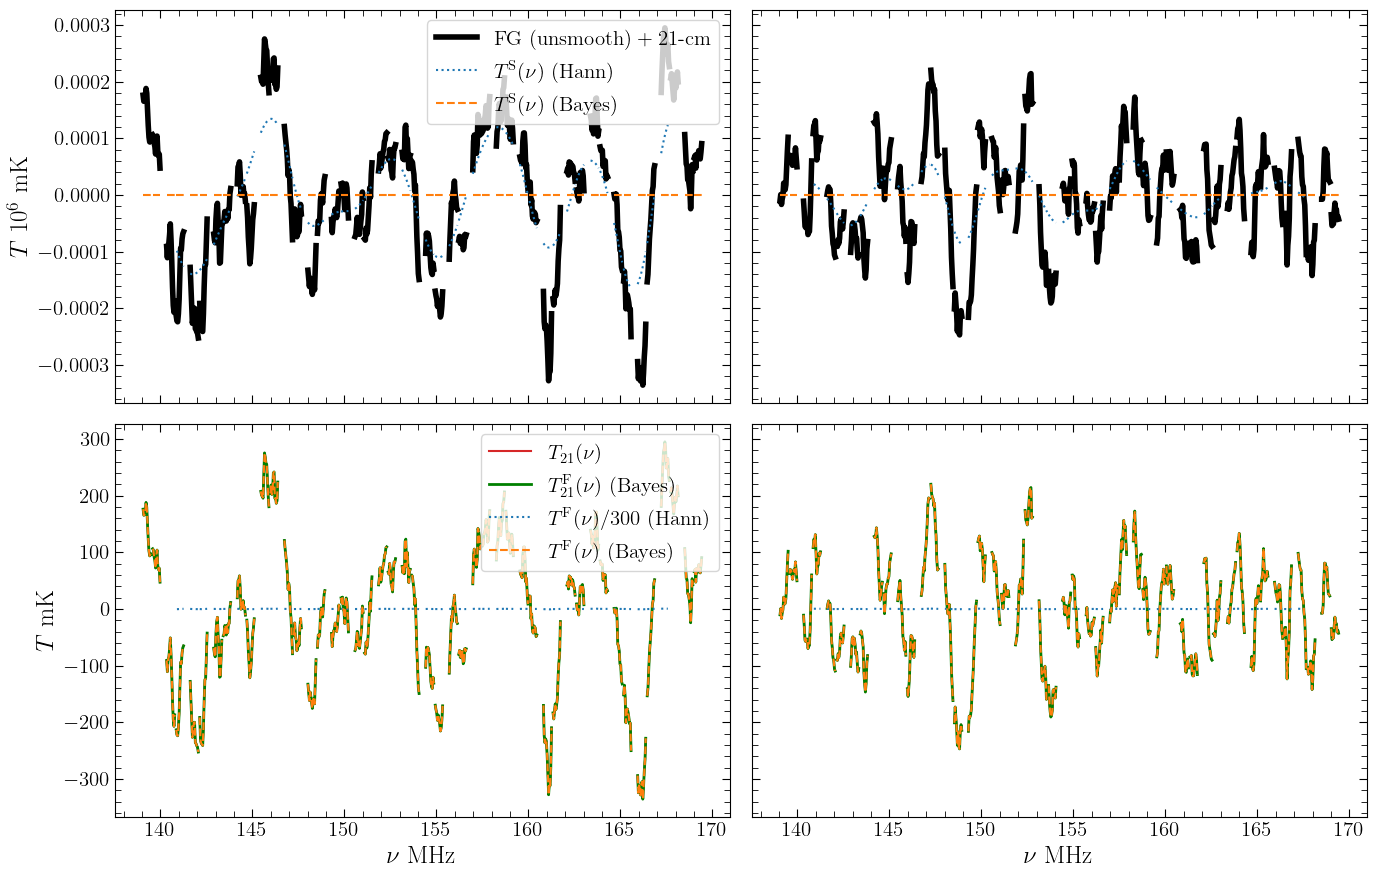

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# --- Input Model Parameters ---
n = 2.0
N = 768
dnuc = 40e-3             # MHz
r = 9209.714526830916    # Mpc
rp = 16.98990953034521   # Mpc/MHz
dL = dnuc * rp
L  = N * dL
Nrea = 100

# Try loading nua, else create dummy frequency array
try:
    nua = np.load('nua.npy') / 1e6
    dnu = nua
except FileNotFoundError:
    print("Warning: 'nua.npy' not found. Using linear range.")
    dnu = np.arange(N) * dnuc + 138.0 

# --- Configuration ---
path = "results"
flag_mode = "PERIODIC"  # Updated to RANDOM
NN_hann = 50 
show_inset = False 

# INDICES for the two realizations
idx1 = 45
# idx1 = 50
idx2 = 90 

# --- Helper to load data ---
def get_data(inp_sig, scf_method, idx):
    fname = f"{path}/fields_inp_signal-{inp_sig}_flag-{flag_mode}_SCF-{scf_method}.npz"
    if not os.path.exists(fname):
        print(f"File not found: {fname}")
        return None, None, None
    data = np.load(fname)
    orig = data.get("fields_orig", None)
    val_orig = orig[idx] if (orig is not None and len(orig) > idx) else None
    return data["fields_tota"][idx], data["fields_flag"][idx], val_orig

def get_data21(inp_sig, scf_method, idx):
    # Loads NOFLAG data for the "Truth"
    # flag_mode = 'NOFLAG'
    fname = f"{path}/fields_inp_signal-{inp_sig}_flag-{flag_mode}_SCF-{scf_method}.npz"
    if not os.path.exists(fname):
        print(f"File not found: {fname}")
        return None, None, None
    data = np.load(fname)
    orig = data.get("fields_orig", None)
    val_orig = orig[idx] if (orig is not None and len(orig) > idx) else None
    return data["fields_tota"][idx], data["fields_flag"][idx], val_orig
    
# --- Plotting Logic for Single Column ---
def plot_realization(ax_top, ax_bot, idx, show_ylabel=True, show_legend=False):
    # Load Data
    tota_fg_hann, res_hann, _ = get_data("21cm", "Hann", idx=idx) 
    tota_fg_gp,   res_gp, _   = get_data("21cm", "GP",   idx=idx) 
    
    # Load True 21cm (Filtered Residuals from NOFLAG run)
    _, true_21cm_none, _ = get_data21("21cm", "None", idx=idx) 
    _, true_21cm, _ = get_data21("21cm", "GP", idx=idx) 
    _, true_21cm_hann, _ = get_data21("21cm", "Hann", idx=idx) 

    if res_hann is None or res_gp is None or true_21cm is None:
        print(f"Error: Missing files for idx {idx}.")
        return

    # Data Prep
    x_full = dnu
    flag_mask = (res_gp != 0.0)
    
    tota_fg_flagged = tota_fg_gp.copy()
    tota_fg_flagged[~flag_mask] = np.nan 
    true_21cm[~flag_mask] = np.nan 
    true_21cm_none[~flag_mask] = np.nan 
    
    # Fits
    fit_gp = tota_fg_gp - res_gp
    fit_gp[~flag_mask] = np.nan
    
    x_hann = x_full[NN_hann : -NN_hann]
    tota_hann_cut = tota_fg_hann[NN_hann : -NN_hann]
    fit_hann = tota_hann_cut - res_hann
    mask_hann = flag_mask[NN_hann : -NN_hann]
    fit_hann[~mask_hann] = np.nan
    true_21cm_hann[~mask_hann] = np.nan 
    
    # Residuals
    res_gp_masked = res_gp.copy()
    res_gp_masked[~flag_mask] = np.nan
    
    res_hann_masked = res_hann.copy()
    res_hann_masked[res_hann_masked == 0] = np.nan
    
    # --- GLOBAL FONT SIZES ---
    FS_LABEL = 18 
    FS_TICK  = 15 
    FS_LEG   = 15 

    ax_top.tick_params(axis='both', which='major', labelsize=FS_TICK)
    ax_bot.tick_params(axis='both', which='major', labelsize=FS_TICK)

    # --- Top Panel: Input + Fits ---
    # Data (Black Solid)
    ax_top.plot(x_full, tota_fg_flagged/1e6, color='k', linewidth=4, 
                label=r"$\mathrm{FG\ (unsmooth) + 21\mbox{-}cm}$") 
    
    # Hann Fit (Blue Dashed)
    ax_top.plot(x_hann, fit_hann/1e6, color='tab:blue', linestyle=':',  linewidth=1.5,
                label=r'$T^{\mathrm{S}}(\nu) \ \mathrm{(Hann)}$')
    
    # GP Fit (Orange Dash-Dot)
    ax_top.plot(x_full, fit_gp/1e6, color='tab:orange', linestyle='--', linewidth=1.5, 
                label=r'$T^{\mathrm{S}}(\nu) \ \mathrm{(Bayes)}$')
    
    if show_ylabel:
        ax_top.set_ylabel(r"$T \ 10^6 \ \mathrm{mK}$", fontsize=FS_LABEL)
    
    if show_legend:
        ax_top.legend(loc="upper right", frameon=True, fontsize=FS_LEG) 
        
    # --- Optional Inset ---
    if show_inset:
        center_idx = N // 2
        zoom_width = 64
        zoom_slice = slice(center_idx - zoom_width, center_idx + zoom_width)
        x_zoom = x_full[zoom_slice]
        y_zoom = tota_fg_flagged[zoom_slice]
        
        axins = ax_top.inset_axes([0.05, 0.65, 0.35, 0.35]) 
        axins.plot(x_full, tota_fg_flagged, color='k', )
        axins.plot(x_hann, fit_hann, color='tab:blue', linestyle=':', linewidth=1.5,)
        axins.plot(x_full, fit_gp, color='tab:orange', linestyle='--', linewidth=1.5,)
        axins.set_xlim(x_zoom[0], x_zoom[-1])
        y_min_zoom = np.nanmin(y_zoom)
        y_max_zoom = np.nanmax(y_zoom)
        y_margin = (y_max_zoom - y_min_zoom) * 0.0
        axins.set_ylim(y_min_zoom - y_margin, y_max_zoom + y_margin)
        axins.tick_params(axis='both', which='major', labelsize=12)
        mark_inset(ax_top, axins, loc1=2, loc2=4, fc="none", ec="0.5")

    # --- Bottom Panel: Residuals ---

    # True 21cm No SCF (red Dashed) 
    ax_bot.plot(x_full, true_21cm_none, color='tab:red', linestyle='-', alpha=1., linewidth=1.5,
             label=r'$T_{21}(\nu)$')

    # True 21cm (Black Solid) - From NOFLAG run (Continuous)
    ax_bot.plot(x_full, true_21cm, color='g', linestyle='-', linewidth=2, 
             label=r'$T^{\mathrm{F}}_{21}(\nu) \ \mathrm{(Bayes)}$')
    # True 21cm Hann (Blue Dashed) - Scaled by 200
    # ax_bot.plot(x_hann, true_21cm_hann, color='tab:blue', linestyle=':', alpha=1., linewidth=1.5,
    #          label=r'$T^{\mathrm{F}}(\nu)/200 \ \mathrm{(Hann)}$')


    # Hann (Blue Dashed) - Scaled by 200
    ax_bot.plot(x_hann, res_hann_masked/300, color='tab:blue', linestyle=':', alpha=1., linewidth=1.5,
             label=r'$T^{\mathrm{F}}(\nu)/300 \ \mathrm{(Hann)}$')
    
    # GP (Orange Dash-Dot)
    ax_bot.plot(x_full, res_gp_masked, color='tab:orange', linestyle='--', alpha=1., linewidth=1.5,
             label=r'$T^{\mathrm{F}}(\nu) \ \mathrm{(Bayes)}$')
    
    if show_ylabel:
        ax_bot.set_ylabel(r"$T \ \mathrm{mK}$", fontsize=FS_LABEL)
    
    ax_bot.set_xlabel(r"$\nu \ \mathrm{MHz}$", fontsize=FS_LABEL)
    
    if show_legend:
        # Adjusted legend to fit nicely
        ax_bot.legend(loc="upper right", ncol=1, frameon=True, fontsize=FS_LEG)


# --- MAIN DRIVER ---

# Create Figure: 2 Rows, 2 Columns
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey='row')

# Plot Realization 1 (Left Column)
plot_realization(axes[0, 0], axes[1, 0], idx1, show_ylabel=True, show_legend=True)

# Plot Realization 2 (Right Column)
plot_realization(axes[0, 1], axes[1, 1], idx2, show_ylabel=False, show_legend=False)

plt.tight_layout()

# Save
save_fname = f"plots/Hann_GP_comparison_{flag_mode}.pdf"
os.makedirs(os.path.dirname(save_fname), exist_ok=True)

plt.savefig(save_fname, dpi=300, bbox_inches='tight')
print(f"Saved: {save_fname}")

plt.show()

In [ ]:
%

In [3]:
# plot window

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.fft import fft, fftshift, fftfreq

# === 1. Parameters ===
N = 768
dnuc = 40e-3             # MHz
# Load Freqs or create dummy
try:
    nua = np.load('nua.npy') 
except FileNotFoundError:
    nua = np.arange(N) * dnuc + 138.0

# Configuration
flag_mode = "NOFLAG" 
idx_plot = 45          

# FILTER WIDTHS (CRITICAL FOR SLICING)
NN_stiff = 50          # Width for 'results'
NN_flex = 10           # Width for 'results1'
pad_diff = NN_stiff - NN_flex 

# PATHS
path_stiff = "results"
path_flex  = "results1"

# === 2. Data Loading Logic ===

def get_data(path_in, inp_sig, scf_method, idx):
    fname = f"{path_in}/fields_inp_signal-{inp_sig}_flag-{flag_mode}_SCF-{scf_method}.npz"
    if not os.path.exists(fname):
        print(f"File not found: {fname}")
        return None, None
    
    data = np.load(fname)
    total = data["fields_tota"][idx]
    resid = data["fields_flag"][idx]
    return total, resid

def compute_delay_spec(signal):
    """Computes Delay Spectrum with windowing."""
    win = np.blackman(len(signal))
    spec = np.abs(fftshift(fft(signal * win)))
    delays = fftshift(fftfreq(len(signal), d=dnuc))
    return delays, spec

def get_components_aligned(path_in, inp_sig_name, idx, NN_current):
    """Loads data and ALIGNS it to the NN_stiff (N=50) grid."""
    total_time, res_time = get_data(path_in, inp_sig_name, "Hann", idx)
    
    if total_time is None or res_time is None:
        return None, None, None, None

    # Slice Total to match Residuals (which are already sliced by NN_current)
    total_valid = total_time[NN_current : -NN_current]
    
    # Fallback check
    if len(total_valid) != len(res_time):
        if len(total_time) == len(res_time):
            total_valid = total_time
            
    # ALIGN TO COMMON GRID (Trim N=10 to match N=50)
    if NN_current < NN_stiff:
        trim = NN_stiff - NN_current
        t_final = total_valid[trim : -trim]
        r_final = res_time[trim : -trim]
    else:
        t_final = total_valid
        r_final = res_time
        
    m_final = t_final - r_final
    
    delays, spec_total = compute_delay_spec(t_final)
    _,      spec_model = compute_delay_spec(m_final)
    _,      spec_res   = compute_delay_spec(r_final)
    
    return delays, spec_total, spec_model, spec_res

# === 3. Main Execution ===

# A. Load Stiff (N=50)
d_s_stiff, T_s_stiff, M_s_stiff, R_s_stiff = get_components_aligned(path_stiff, "FG+21cm", idx_plot, NN_stiff)
d_u_stiff, T_u_stiff, M_u_stiff, R_u_stiff = get_components_aligned(path_stiff, "FG+MM+21cm", idx_plot, NN_stiff)

# B. Load Flex (N=10)
d_s_flex, T_s_flex, M_s_flex, R_s_flex = get_components_aligned(path_flex, "FG+21cm", idx_plot, NN_flex)
d_u_flex, T_u_flex, M_u_flex, R_u_flex = get_components_aligned(path_flex, "FG+MM+21cm", idx_plot, NN_flex)

# C. Load TRUTH (Pure 21cm Input) - No FG
# We reuse the N=50 loader so it aligns with the Stiff plots
d_21, T_21, _, _ = get_components_aligned(path_stiff, "21cm", idx_plot, NN_stiff)


# === 4. PLOTTING ===
plt.rcParams.update({'font.family': 'serif', 'mathtext.fontset': 'cm'})

if d_u_stiff is not None and d_u_flex is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    
    # Use STRICTLY POSITIVE delays for log scale
    mask = d_s_stiff > 0 
    
    # --- PANEL A: SMOOTH FOREGROUNDS ---
    ax0 = axes[0]
    
    # 1. Total Input
    ax0.loglog(d_s_stiff[mask], T_s_stiff[mask], 'k-', lw=4, alpha=0.2, label=r'$\mathrm{FG+21\mbox{-}cm}$')
    
    # 2. Truth (Pure 21cm)
    ax0.loglog(d_21[mask], T_21[mask], 'k-', lw=1.5, alpha=0.8, label=r'$\mathrm{21\mbox{-}cm}$')
    
    # 3. Stiff (N=50)
    ax0.loglog(d_s_stiff[mask], M_s_stiff[mask], 'b--', lw=2, label=r'$T^{\mathrm{S}}\ (N=50)$')
    ax0.loglog(d_s_stiff[mask], R_s_stiff[mask], 'r-', lw=1.5, alpha=0.8, label=r'$T^{\mathrm{F}}\ (N=50)$')

    # 4. Flex (N=10)
    ax0.loglog(d_s_flex[mask], M_s_flex[mask], color='cyan', linestyle=':', lw=2, label=r'$T^{\mathrm{S}}\ (N=10)$')
    ax0.loglog(d_s_flex[mask], R_s_flex[mask], color='magenta', linestyle='--', lw=1.5, alpha=0.8, label=r'$T^{\mathrm{F}}\ (N=10)$')
    
    # Log Formatting
    ax0.set_xlabel(r'$ \tau \ \mu\mathrm{s} $', fontsize=14)
    ax0.set_ylabel(r'$\mid \tilde{T}(\tau) \mid$', fontsize=14)
    ax0.set_title(r'$\mathrm{\mathbf{FG:} \ Smooth} \quad \mathrm{\mathbf{SCF:} \ Hann}$', fontsize=14) # Fixed Title
    ax0.grid(True, alpha=0.3, which='both')
    ax0.legend()

    # --- PANEL B: UNSMOOTH FOREGROUNDS ---
    ax1 = axes[1]
    
    # 1. Total Input
    ax1.loglog(d_u_stiff[mask], T_u_stiff[mask], 'k-', lw=4, alpha=0.2, label=r'$\mathrm{Total\ Input}$')
    
    # 2. Truth (Pure 21cm)
    ax1.loglog(d_21[mask], T_21[mask], 'k-', lw=1.5, alpha=0.8, label=r'$\mathrm{Input\ 21\mbox{-}cm}$')
    
    # 3. Stiff (N=50)
    ax1.loglog(d_u_stiff[mask], M_u_stiff[mask], 'b--', lw=2, label=r'$\mathrm{Model\ (}N=50\mathrm{)}$')
    ax1.loglog(d_u_stiff[mask], R_u_stiff[mask], 'r-', lw=1.5, alpha=0.8, label=r'$\mathrm{Resid\ (}N=50\mathrm{)}$')
    
    # 4. Flex (N=10)
    ax1.loglog(d_u_flex[mask], M_u_flex[mask], color='cyan', linestyle=':', lw=2, label=r'$\mathrm{Model\ (}N=10\mathrm{)}$')
    ax1.loglog(d_u_flex[mask], R_u_flex[mask], color='magenta', linestyle='--', lw=1.5, alpha=0.8, label=r'$\mathrm{Resid\ (}N=10\mathrm{)}$')
    
    # Annotations
    bump_idx = np.argmin(np.abs(d_u_stiff[mask] - 0.2)) 
    
    # Log Formatting
    ax1.set_xlabel(r'$ \tau\ \mu\mathrm{s}$', fontsize=14)
    ax1.set_title(r'$\mathrm{\mathbf{FG:} \ Unsmooth} \quad \mathrm{\mathbf{SCF:} \ Hann}$', fontsize=14)
    ax1.grid(True, alpha=0.3, which='both')
    # ax1.legend(loc='lower left', fontsize=10)
    
    plt.tight_layout()
    
    save_fname = f"plots/Hann_delay.pdf"
    os.makedirs("plots", exist_ok=True)
    plt.savefig(save_fname, bbox_inches='tight')
    print(f"Plot saved to {save_fname}")
    plt.show()

else:
    print("Error: Could not load data.")

File not found: results1/fields_inp_signal-FG+21cm_flag-NOFLAG_SCF-Hann.npz
File not found: results1/fields_inp_signal-FG+MM+21cm_flag-NOFLAG_SCF-Hann.npz
Error: Could not load data.


/var/folders/1v/cbxr_1rs0yb7884f6y71fxyw0000gn/T/ipykernel_9205/1970320460.py:130: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Plot saved to plots/GP_delay.pdf


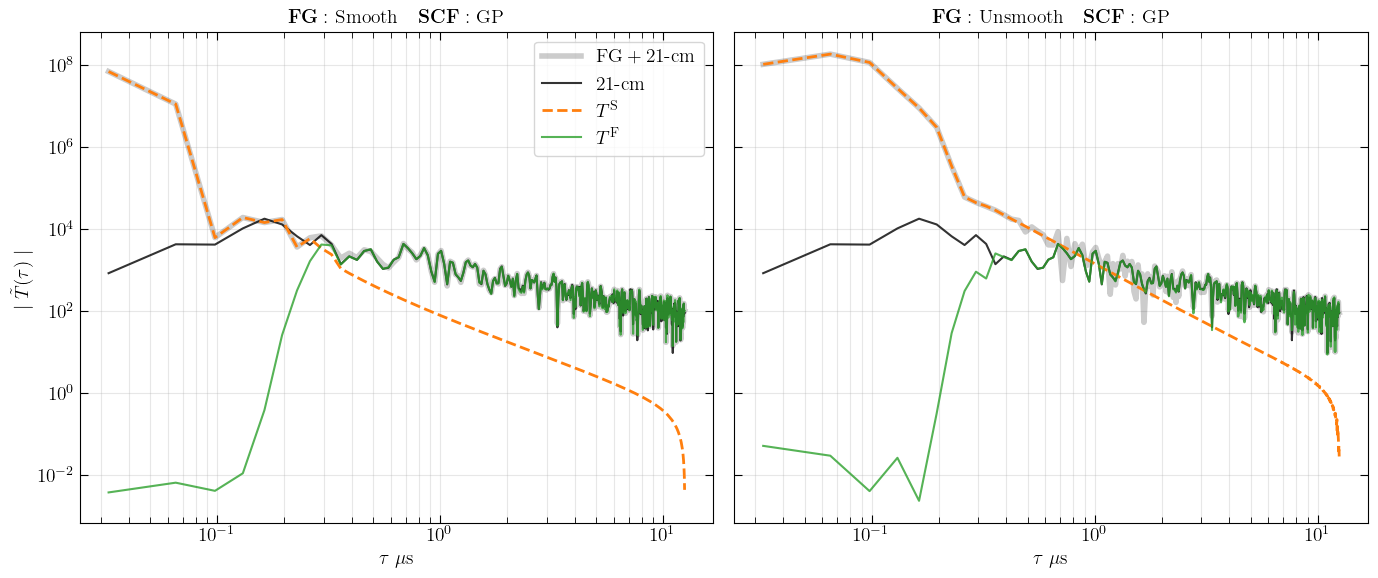

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.fft import fft, fftshift, fftfreq

# === 1. Parameters ===
N = 768
dnuc = 40e-3             # MHz
# Load Freqs or create dummy
try:
    nua = np.load('nua.npy') 
except FileNotFoundError:
    nua = np.arange(N) * dnuc + 138.0

# Configuration
path = "results"
flag_mode = "NOFLAG" 
idx_plot = 45          

# === 2. Data Loading Logic ===

def get_data_gp(inp_sig, idx):
    """Loads GP results. No slicing required."""
    fname = f"{path}/fields_inp_signal-{inp_sig}_flag-{flag_mode}_SCF-GP.npz"
    if not os.path.exists(fname):
        print(f"File not found: {fname}")
        return None, None
    
    data = np.load(fname)
    # Index 0 -> Total Data
    # Index 1 -> Residuals (fields_flag in your structure)
    total = data["fields_tota"][idx]
    resid = data["fields_flag"][idx]
    
    return total, resid


def get_components_gp(inp_sig_name, idx):
    """Loads GP data and computes spectra (Full Array)."""
    t_final, r_final = get_data_gp(inp_sig_name, idx)
    
    if t_final is None or r_final is None:
        return None, None, None, None

    # Compute Model
    m_final = t_final - r_final
    
    # Compute Spectra
    delays, spec_total = compute_delay_spec(t_final)
    _,      spec_model = compute_delay_spec(m_final)
    _,      spec_res   = compute_delay_spec(r_final)
    
    return delays, spec_total, spec_model, spec_res

# === 3. Main Execution ===

# A. Load Smooth Case (FG + 21cm)
d_s, T_s, M_s, R_s = get_components_gp("FG+21cm", idx_plot)

# B. Load Unsmooth Case (FG + MM + 21cm)
d_u, T_u, M_u, R_u = get_components_gp("FG+MM+21cm", idx_plot)

# C. Load TRUTH (Pure 21cm Input) - No FG
# We just need the "Total" from this file, as it is the pure signal
d_21, T_21, _, _ = get_components_gp("21cm", idx_plot)


# === 4. PLOTTING ===
plt.rcParams.update({'font.family': 'serif', 'mathtext.fontset': 'cm'})

if d_u is not None and d_21 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    
    # Use STRICTLY POSITIVE delays for log scale
    mask = d_s > 0 
    
    # --- PANEL A: SMOOTH FOREGROUNDS ---
    ax0 = axes[0]
    
    # 1. Total Input (FG + 21cm)
    ax0.loglog(d_s[mask], T_s[mask], 'k-', lw=4, alpha=0.2, label=r'$\mathrm{FG+21\mbox{-}cm}$')
    
    # 2. Truth (Pure 21cm)
    ax0.loglog(d_21[mask], T_21[mask], 'k-', lw=1.5, alpha=0.8, label=r'$\mathrm{21\mbox{-}cm}$')

    # 3. GP Results
    ax0.loglog(d_s[mask], M_s[mask], color='tab:orange', linestyle='--', lw=2, label=r'$T^{\mathrm{S}}$')
    ax0.loglog(d_s[mask], R_s[mask], color='tab:green', linestyle='-', lw=1.5, alpha=0.8, label=r'$T^{\mathrm{F}}$')


    
    # Log Formatting
    # Set ylim to see the signal (which is much lower than FG)
    # ax0.set_ylim(1e-4, np.max(T_s)*3) 
    ax0.set_xlabel(r'$ \tau \ \mu\mathrm{s} $', fontsize=14)
    ax0.set_ylabel(r'$\mid \tilde{T}(\tau) \mid$', fontsize=14)
    ax0.set_title(r'$\mathrm{\mathbf{FG:} \ Smooth} \quad \mathrm{\mathbf{SCF:} \ GP}$', fontsize=14) # Fixed Title
    ax0.grid(True, alpha=0.3, which='both')
    ax0.legend()

    # --- PANEL B: UNSMOOTH FOREGROUNDS ---
    ax1 = axes[1]
    
    # 1. Total Input
    ax1.loglog(d_u[mask], T_u[mask], 'k-', lw=4, alpha=0.2, label=r'$\mathrm{Total\ Input}$')
    
    # 2. Truth (Pure 21cm)
    ax1.loglog(d_21[mask], T_21[mask], 'k-', lw=1.5, alpha=0.8, label=r'$\mathrm{Input\ 21\mbox{-}cm}$')
    
    # 3. GP Results
    ax1.loglog(d_u[mask], M_u[mask], color='tab:orange', linestyle='--', lw=2, label=r'$\mathrm{GP\ Model}$')
    ax1.loglog(d_u[mask], R_u[mask], color='tab:green', linestyle='-', lw=1.5, alpha=0.8, label=r'$\mathrm{GP\ Resid}$')
    
    # Annotate Leakage (if visible above 21cm)
    # Find where Residual > Truth significantly
    bump_idx = np.argmin(np.abs(d_u[mask] - 0.2)) 
    
    # ax1.annotate(r'$\mathrm{Residuals\ \approx\ Truth}$', 
    #              xy=(0.2, R_u[mask][bump_idx]), 
    #              xytext=(0.05, R_u[mask][bump_idx]*10), 
    #              arrowprops=dict(facecolor='tab:green', arrowstyle='->', lw=1.5),
    #              fontsize=11, fontweight='bold', color='tab:green')

    # Log Formatting
    ax1.set_xlabel(r'$ \tau\ \mu\mathrm{s}$', fontsize=14)
    ax1.set_title(r'$\mathrm{\mathbf{FG:} \ Unsmooth} \quad \mathrm{\mathbf{SCF:} \ GP}$', fontsize=14)
    ax1.grid(True, alpha=0.3, which='both')
    # ax1.legend(loc='lower left', fontsize=10)
    
    plt.tight_layout()
    
    save_fname = f"plots/GP_delay.pdf"
    os.makedirs("plots", exist_ok=True)
    plt.savefig(save_fname, bbox_inches='tight')
    print(f"Plot saved to {save_fname}")
    plt.show()

else:
    print("Error: Could not load data.")

/var/folders/1v/cbxr_1rs0yb7884f6y71fxyw0000gn/T/ipykernel_9205/799581531.py:144: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Plot saved to plots/Hann_GP_comparison_NOFLAG_delay.pdf


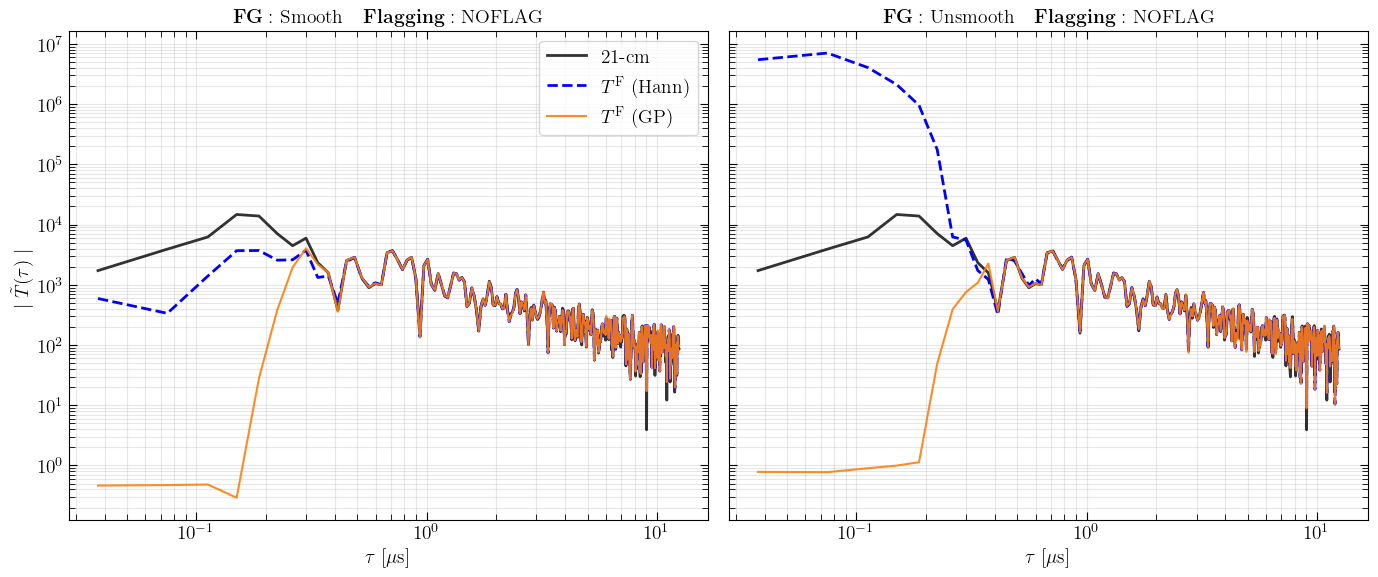

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.fft import fft, fftshift, fftfreq

# === 1. Parameters ===
N = 768
dnuc = 40e-3             # MHz
# Load Freqs or create dummy
try:
    nua = np.load('nua.npy') 
except FileNotFoundError:
    nua = np.arange(N) * dnuc + 138.0

# Configuration
path = "results"
flag_mode = "NOFLAG" 
idx_plot = 45          
NN_hann = 50             # The 'Stiff' cut used for Hann

# === 2. Data Loading Logic ===

def get_raw_data(inp_sig, scf_method, idx):
    """Loads raw Total and Residuals from files."""
    fname = f"{path}/fields_inp_signal-{inp_sig}_flag-{flag_mode}_SCF-{scf_method}.npz"
    if not os.path.exists(fname):
        print(f"File not found: {fname}")
        return None, None
    
    data = np.load(fname)
    total = data["fields_tota"][idx]
    resid = data["fields_flag"][idx]
    return total, resid


def get_aligned_spectra(inp_sig_name, idx):
    """
    Loads Hann and GP data for a specific input signal.
    Slices EVERYTHING to the Hann valid region (NN_hann:-NN_hann)
    so they can be plotted on the same delay axis.
    """
    # 1. Load Hann (Already sliced in some versions, but let's be safe)
    # The 'fields_flag' in Hann files is usually the residual
    t_hann_raw, r_hann_raw = get_raw_data(inp_sig_name, "Hann", idx)
    
    # 2. Load GP (Full N=768)
    t_gp_raw, r_gp_raw = get_raw_data(inp_sig_name, "GP", idx)
    
    if t_hann_raw is None or t_gp_raw is None:
        return None, None, None, None, None

    # --- ALIGNMENT STEP ---
    # We must cut everyone to the common valid region: [50 : -50]
    valid_slice = slice(NN_hann, -NN_hann)
    
    # Handle Hann: Check if it's full size or already sliced
    if len(r_hann_raw) == N:
        r_hann_valid = r_hann_raw[valid_slice]
    else:
        # Assume it's already sliced if length matches N - 2*NN
        r_hann_valid = r_hann_raw 

    # Handle GP: Always full size, so we slice it
    r_gp_valid = r_gp_raw[valid_slice]
    
    # Handle Total Input (Use GP's total, sliced, as reference)
    t_valid = t_gp_raw[valid_slice]

    # Compute Spectra
    delays, spec_total = compute_delay_spec(t_valid)
    _,      spec_r_hann = compute_delay_spec(r_hann_valid)
    _,      spec_r_gp   = compute_delay_spec(r_gp_valid)
    
    return delays, spec_total, spec_r_hann, spec_r_gp

# === 3. Main Execution ===

# A. Smooth Case (FG + 21cm)
d_s, T_s, R_s_Hann, R_s_GP = get_aligned_spectra("FG+21cm", idx_plot)

# B. Unsmooth Case (FG + MM + 21cm)
d_u, T_u, R_u_Hann, R_u_GP = get_aligned_spectra("FG+MM+21cm", idx_plot)

# C. Truth (Pure 21cm) - Load from GP file and slice
t_21_raw, _ = get_raw_data("21cm", "GP", idx_plot)
if t_21_raw is not None:
    t_21_valid = t_21_raw[slice(NN_hann, -NN_hann)]
    _, spec_21 = compute_delay_spec(t_21_valid)
else:
    spec_21 = None


# === 4. PLOTTING ===
plt.rcParams.update({'font.family': 'serif', 'mathtext.fontset': 'cm'})

if d_u is not None and spec_21 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    
    # Use STRICTLY POSITIVE delays for log scale
    mask = d_s > 0 
    
    # --- PANEL A: SMOOTH FOREGROUNDS ---
    ax0 = axes[0]
    
    # 1. Total Input
    # ax0.loglog(d_s[mask], T_s[mask], 'k-', lw=4, alpha=0.2, label=r'$\mathrm{FG + 21\mbox{-}cm}$')
    
    # 2. Truth (21cm)
    ax0.loglog(d_s[mask], spec_21[mask], 'k-', lw=2, alpha=0.8, label=r'$\mathrm{21\mbox{-}cm}$')
    
    # 3. Residuals Comparison
    ax0.loglog(d_s[mask], R_s_Hann[mask], 'b--', lw=2, label=r'$T^{\mathrm{F}} \ (\mathrm{Hann})$')
    ax0.loglog(d_s[mask], R_s_GP[mask], color='tab:orange', linestyle='-', lw=1.5, alpha=0.9, label=r'$T^{\mathrm{F}} \ (\mathrm{GP})$')
    
    # Formatting
    ax0.set_xlabel(r'$ \tau \ [\mu\mathrm{s}] $', fontsize=14)
    ax0.set_ylabel(r'$\mid \tilde{T}(\tau) \mid$', fontsize=14)
    ax0.set_title(r'$\mathrm{\mathbf{FG:} \ Smooth} \quad \mathrm{\mathbf{Flagging:} \ NOFLAG}$', fontsize=14)
    ax0.grid(True, alpha=0.3, which='both')
    ax0.legend()

    # --- PANEL B: UNSMOOTH FOREGROUNDS ---
    ax1 = axes[1]
    
    # 1. Total Input
    # ax1.loglog(d_u[mask], T_u[mask], 'k-', lw=4, alpha=0.2, label=r'$\mathrm{Total\ Input}$')
    
    # 2. Truth (21cm)
    ax1.loglog(d_u[mask], spec_21[mask], 'k-', lw=2, alpha=0.8, label=r'$\mathrm{21\mbox{-}cm}$')
    
    # 3. Residuals Comparison
    ax1.loglog(d_u[mask], R_u_Hann[mask], 'b--', lw=2, label=r'$T^{\mathrm{F}} \ (\mathrm{Hann})$')
    ax1.loglog(d_u[mask], R_u_GP[mask], color='tab:orange', linestyle='-', lw=1.5, alpha=0.9, label=r'$T^{\mathrm{F}} \ (\mathrm{GP})$')
    
    # Annotate the Failure
    # Find bump near 0.2 us
    bump_idx = np.argmin(np.abs(d_u[mask] - 0.2))
    
    # Formatting
    ax1.set_xlabel(r'$ \tau \ [\mu\mathrm{s}] $', fontsize=14)
    ax1.set_title(r'$\mathrm{\mathbf{FG:} \ Unsmooth} \quad \mathrm{\mathbf{Flagging:} \ NOFLAG}$', fontsize=14)
    ax1.grid(True, alpha=0.3, which='both')
    
    plt.tight_layout()
    
    save_fname = f"plots/Hann_GP_comparison_{flag_mode}_delay.pdf" 
    os.makedirs("plots", exist_ok=True)
    plt.savefig(save_fname, bbox_inches='tight')
    print(f"Plot saved to {save_fname}")
    plt.show()

else:
    print("Error: Could not load data.")

/var/folders/1v/cbxr_1rs0yb7884f6y71fxyw0000gn/T/ipykernel_9205/931469595.py:140: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Plot saved to plots/Hann_GP_comparison_PERIODIC_delay.pdf


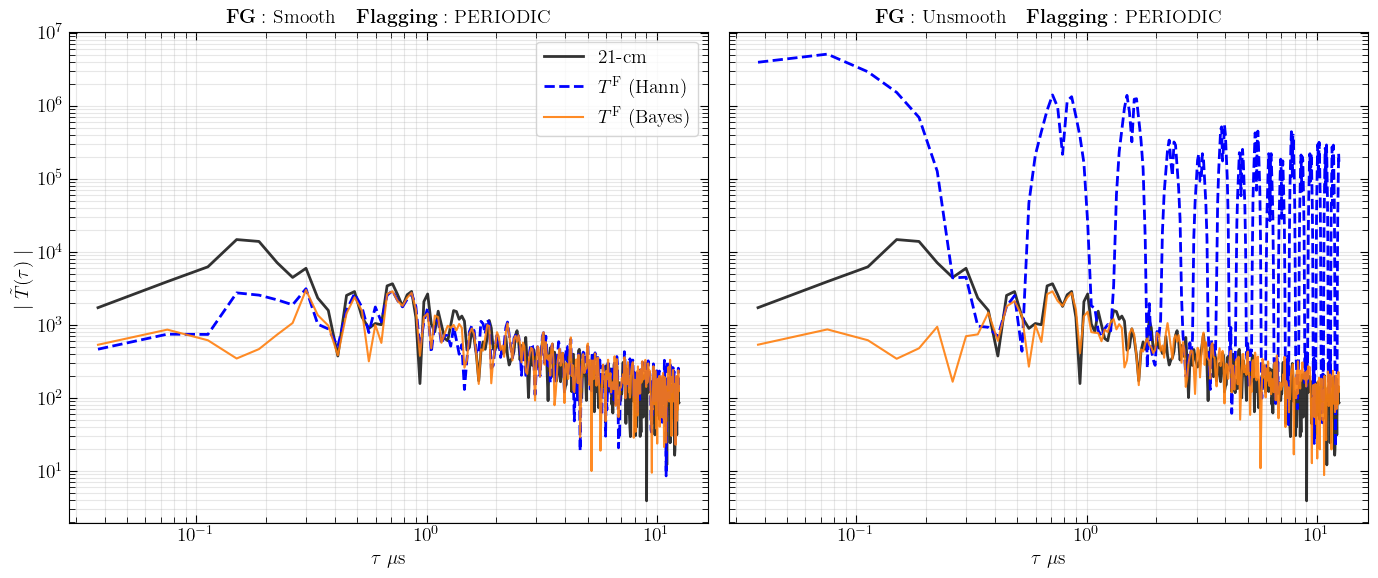

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.fft import fft, fftshift, fftfreq

# === 1. Parameters ===
N = 768
dnuc = 40e-3             # MHz
# Load Freqs or create dummy
try:
    nua = np.load('nua.npy') 
except FileNotFoundError:
    nua = np.arange(N) * dnuc + 138.0

# Configuration
path = "results"
flag_mode = "PERIODIC" 
idx_plot = 45          
NN_hann = 50             # The 'Stiff' cut used for Hann

# === 2. Data Loading Logic ===

def get_raw_data(inp_sig, scf_method, idx):
    """Loads raw Total and Residuals from files."""
    fname = f"{path}/fields_inp_signal-{inp_sig}_flag-{flag_mode}_SCF-{scf_method}.npz"
    if not os.path.exists(fname):
        print(f"File not found: {fname}")
        return None, None
    
    data = np.load(fname)
    total = data["fields_tota"][idx]
    resid = data["fields_flag"][idx]
    return total, resid


def get_aligned_spectra(inp_sig_name, idx):
    """
    Loads Hann and GP data for a specific input signal.
    Slices EVERYTHING to the Hann valid region (NN_hann:-NN_hann)
    so they can be plotted on the same delay axis.
    """
    # 1. Load Hann 
    t_hann_raw, r_hann_raw = get_raw_data(inp_sig_name, "Hann", idx)
    
    # 2. Load GP 
    t_gp_raw, r_gp_raw = get_raw_data(inp_sig_name, "GP", idx)
    
    if t_hann_raw is None or t_gp_raw is None:
        return None, None, None, None, None

    # --- ALIGNMENT STEP ---
    # We must cut everyone to the common valid region: [50 : -50]
    valid_slice = slice(NN_hann, -NN_hann)
    
    # Handle Hann: Check if it's full size or already sliced
    if len(r_hann_raw) == N:
        r_hann_valid = r_hann_raw[valid_slice]
    else:
        # Assume it's already sliced if length matches N - 2*NN
        r_hann_valid = r_hann_raw 

    # Handle GP: Always full size, so we slice it
    r_gp_valid = r_gp_raw[valid_slice]
    
    # Handle Total Input (Use GP's total, sliced, as reference)
    t_valid = t_gp_raw[valid_slice]

    # Compute Spectra
    delays, spec_total = compute_delay_spec(t_valid)
    _,      spec_r_hann = compute_delay_spec(r_hann_valid)
    _,      spec_r_gp   = compute_delay_spec(r_gp_valid)
    
    return delays, spec_total, spec_r_hann, spec_r_gp

# === 3. Main Execution ===

# A. Smooth Case (FG + 21cm)
d_s, T_s, R_s_Hann, R_s_GP = get_aligned_spectra("FG+21cm", idx_plot)

# B. Unsmooth Case (FG + MM + 21cm)
d_u, T_u, R_u_Hann, R_u_GP = get_aligned_spectra("FG+MM+21cm", idx_plot)

# C. Truth (Pure 21cm) - Load from GP file and slice
t_21_raw, _ = get_raw_data("21cm", "GP", idx_plot)
if t_21_raw is not None:
    t_21_valid = t_21_raw[slice(NN_hann, -NN_hann)]
    _, spec_21 = compute_delay_spec(t_21_valid)
else:
    spec_21 = None


# === 4. PLOTTING ===
plt.rcParams.update({'font.family': 'serif', 'mathtext.fontset': 'cm'})

if d_u is not None and spec_21 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    
    # Use STRICTLY POSITIVE delays for log scale
    mask = d_s > 0 
    
    # --- PANEL A: SMOOTH FOREGROUNDS ---
    ax0 = axes[0]
    
    # 1. Total Input
    # ax0.loglog(d_s[mask], T_s[mask], 'k-', lw=4, alpha=0.2, label=r'$\mathrm{FG + 21\mbox{-}cm}$')
    
    # 2. Truth (21cm)
    ax0.loglog(d_s[mask], spec_21[mask], 'k-', lw=2, alpha=0.8, label=r'$\mathrm{21\mbox{-}cm}$')
    
    # 3. Residuals Comparison
    ax0.loglog(d_s[mask], R_s_Hann[mask], 'b--', lw=2, label=r'$T^{\mathrm{F}} \ (\mathrm{Hann})$')
    ax0.loglog(d_s[mask], R_s_GP[mask], color='tab:orange', linestyle='-', lw=1.5, alpha=0.9, label=r'$T^{\mathrm{F}} \ (\mathrm{Bayes})$')
    
    # Formatting
    ax0.set_xlabel(r'$ \tau \ \mu\mathrm{s} $', fontsize=14)
    ax0.set_ylabel(r'$\mid \tilde{T}(\tau) \mid$', fontsize=14)
    ax0.set_title(r'$\mathrm{\mathbf{FG:} \ Smooth} \quad \mathrm{\mathbf{Flagging:} \ PERIODIC}$', fontsize=14)
    ax0.grid(True, alpha=0.3, which='both')
    ax0.legend()

    # --- PANEL B: UNSMOOTH FOREGROUNDS ---
    ax1 = axes[1]
    
    # 1. Total Input
    # ax1.loglog(d_u[mask], T_u[mask], 'k-', lw=4, alpha=0.2, label=r'$\mathrm{Total\ Input}$')
    
    # 2. Truth (21cm)
    ax1.loglog(d_u[mask], spec_21[mask], 'k-', lw=2, alpha=0.8, label=r'$\mathrm{21\mbox{-}cm}$')
    
    # 3. Residuals Comparison
    ax1.loglog(d_u[mask], R_u_Hann[mask], 'b--', lw=2, label=r'$T^{\mathrm{F}} \ (\mathrm{Hann})$')
    ax1.loglog(d_u[mask], R_u_GP[mask], color='tab:orange', linestyle='-', lw=1.5, alpha=0.9, label=r'$T^{\mathrm{F}} \ (\mathrm{Bayes})$')
    
    
    # Formatting
    ax1.set_xlabel(r'$ \tau \ \mu\mathrm{s} $', fontsize=14)
    ax1.set_title(r'$\mathrm{\mathbf{FG:} \ Unsmooth} \quad \mathrm{\mathbf{Flagging:} \ PERIODIC}$', fontsize=14)
    ax1.grid(True, alpha=0.3, which='both')
    
    plt.tight_layout()
    
    save_fname = f"plots/Hann_GP_comparison_{flag_mode}_delay.pdf" 
    os.makedirs("plots", exist_ok=True)
    plt.savefig(save_fname, bbox_inches='tight')
    print(f"Plot saved to {save_fname}")
    plt.show()

else:
    print("Error: Could not load data.")